Exploratory Data Analysis for Pneumonia Detection from Chest X-Ray Images.

The goal of this notebook is to investigate the structure and properties of the
dataset before training a Convolutional Neural Network (CNN). The analysis
identifies issues such as class imbalance, unreliable dataset splits,
image inconsistencies, and potential data quality problems.

Insights obtained here will guide preprocessing, dataset restructuring,
and CNN architecture choices.


In [34]:
### Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from tensorflow.keras import layers
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers

In [35]:
### Install if not yet to explore data path

!command -v tree >/dev/null 2>&1 || apt-get -qq install tree

In [36]:
### Detect GPU

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected:", gpus)

    # prevent TensorFlow from allocating all GPU memory
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected, using CPU")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [38]:
### Download the data

import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset path:", path)
!tree -d -L 3 {path}

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia
/kaggle/input/chest-xray-pneumonia
└── chest_xray
    ├── chest_xray
    │   ├── test
    │   ├── train
    │   └── val
    ├── __MACOSX
    │   └── chest_xray
    ├── test
    │   ├── NORMAL
    │   └── PNEUMONIA
    ├── train
    │   ├── NORMAL
    │   └── PNEUMONIA
    └── val
        ├── NORMAL
        └── PNEUMONIA

16 directories


In [5]:
### Dataset Directory Setup

dataset_path = os.path.join(path, "chest_xray")

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

splits = {
    "train": train_dir,
    "val": val_dir,
    "test": test_dir
}

classes = ["NORMAL", "PNEUMONIA"]

In [6]:
### Dataset Structure Analysis
### Count images in each split

data = []

for split, path in splits.items():
    normal = len(os.listdir(os.path.join(path, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(path, "PNEUMONIA")))

    data.append([split, normal, pneumonia, normal + pneumonia])

df = pd.DataFrame(data, columns=["Split", "NORMAL", "PNEUMONIA", "TOTAL"])
df

,Split,NORMAL,PNEUMONIA,TOTAL
0,train,1341,3875,5216
1,val,8,8,16
2,test,234,390,624


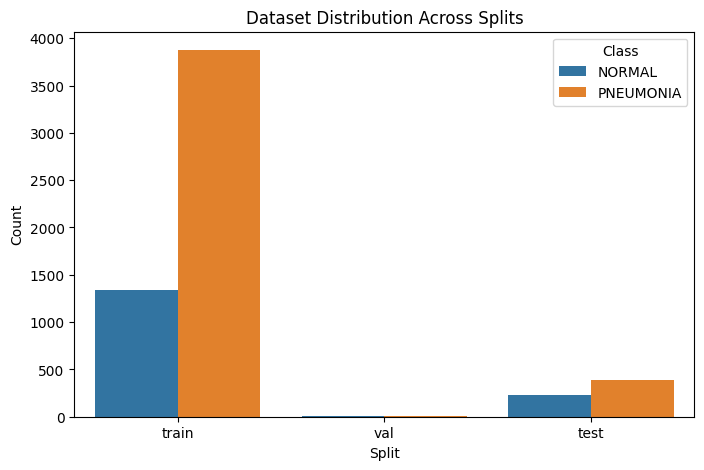

In [7]:
### Visualize Dataset Distribution
df_plot = df.melt("Split", var_name="Class", value_name="Count").query("Class!='TOTAL'")

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_plot,
    x="Split",
    y="Count",
    hue="Class"
)

plt.title("Dataset Distribution Across Splits")
plt.show()

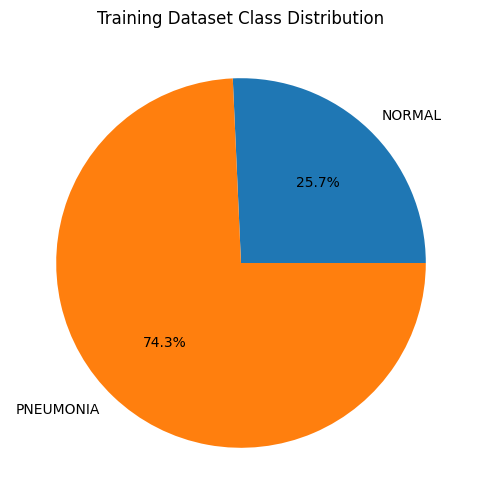

In [8]:
train_counts = df_plot[df_plot.Split == "train"]

plt.figure(figsize=(6,6))

plt.pie(
    train_counts["Count"],
    labels=train_counts["Class"],
    autopct='%1.1f%%'
)

plt.title("Training Dataset Class Distribution")
plt.show()

Observation:
- Extremely Small Validation Set: The validation dataset contains only 16 images.
The validation set must then be reconstructed by splitting the training dataset.

- Severe Class Imbalance in training: The training dataset has approximately a 3:1 imbalance (Normal ≈ 26% and Pneumonia ≈ 74%)
We must use class weighting and data augmentation to reduce class bias.

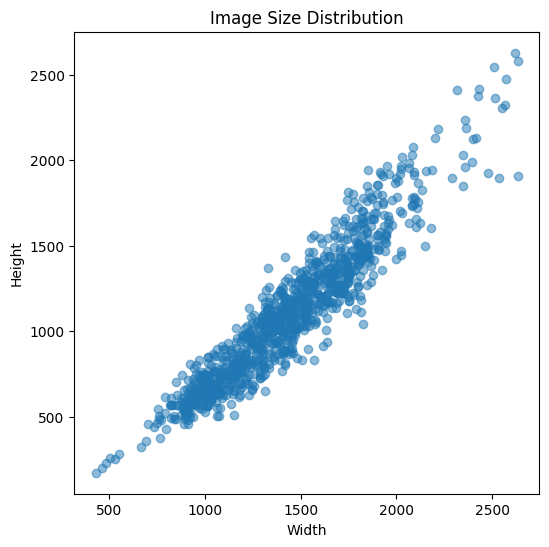

In [9]:
### Image Dimension Analysis

sizes = []

for cls in classes:
    folder = os.path.join(train_dir, cls)

    for img_file in os.listdir(folder)[:500]:

        img_path = os.path.join(folder, img_file)
        img = Image.open(img_path)

        sizes.append(img.size)

sizes = np.array(sizes)

# Plot size distribution
plt.figure(figsize=(6,6))

plt.scatter(sizes[:,0], sizes[:,1], alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

Images appear in multiple resolutions. For modelling our CNN, we will resized them into a constant size of 224 x 224 to enhance model performance and training efficiency

In [10]:
### Check whether images are RGB or grayscale

for split, path in splits.items():
    for cls in ["NORMAL", "PNEUMONIA"]:
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        print(split, cls, img.mode)

train NORMAL L
train PNEUMONIA L
val NORMAL L
val PNEUMONIA L
test NORMAL L
test PNEUMONIA L


Images are all grayscales images

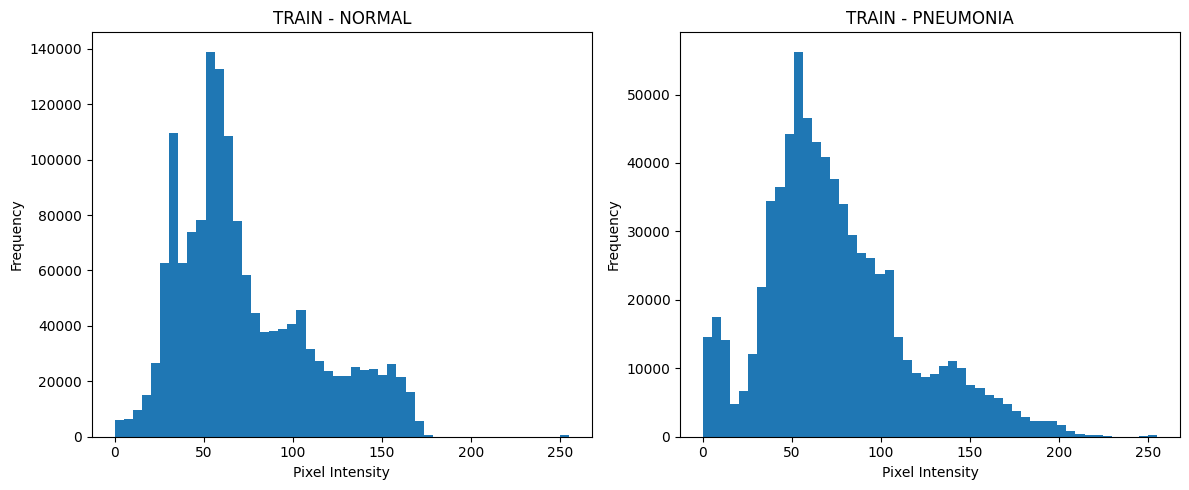

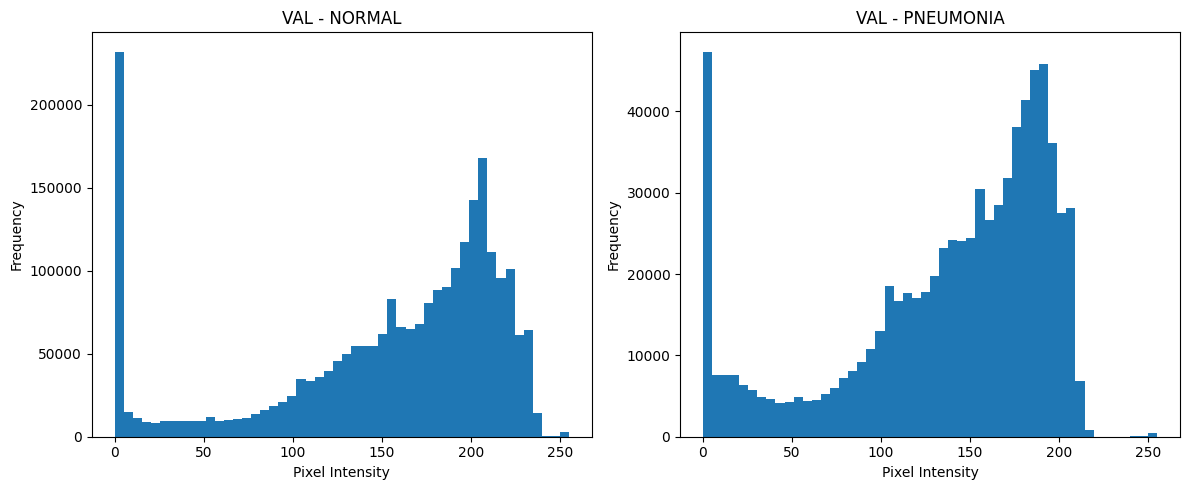

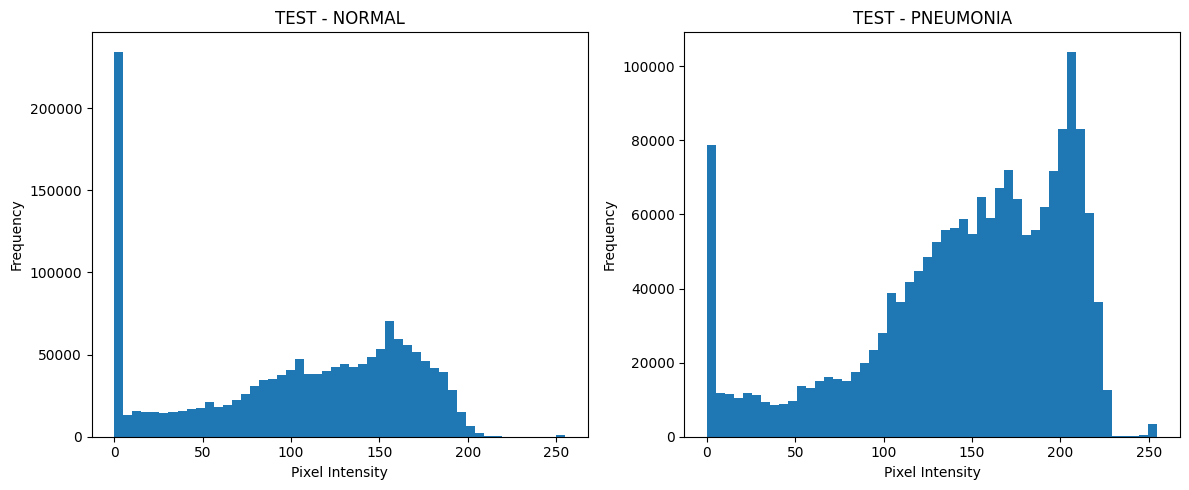

In [11]:
"""img_array = np.array(sample_image)

plt.hist(img_array.flatten(), bins=50)

plt.title("Pixel Intensity Distribution")

plt.show()
"""
for split, path in splits.items():
    plt.figure(figsize=(12, 5))  # wider figure for side-by-side plots

    for i, cls in enumerate(["NORMAL", "PNEUMONIA"]):
        # Load first image of each class
        img_path = os.path.join(path, cls, os.listdir(os.path.join(path, cls))[0])
        img = Image.open(img_path)
        img_array = np.array(img)

        # Plot side by side
        plt.subplot(1, 2, i + 1)
        plt.hist(img_array.flatten(), bins=50)
        plt.title(f"{split.upper()} - {cls}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

Images values are typically range between 0 – 255. Pixel values will be normalized to [0,1] during preprocessing.

In [12]:
### Visual Inspection of Images

def show_samples(label):

    folder = os.path.join(train_dir, label)
    files = os.listdir(folder)[:5]

    plt.figure(figsize=(12,3))

    for i, file in enumerate(files):

        img = Image.open(os.path.join(folder, file))

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(label)
    plt.show()

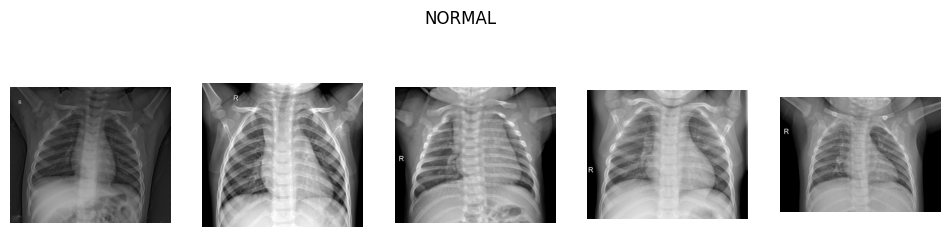

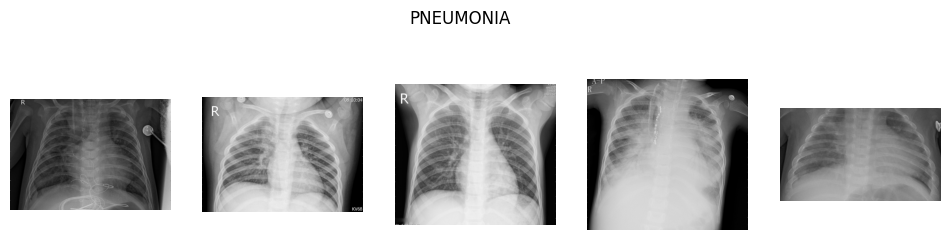

In [13]:
show_samples("NORMAL")
show_samples("PNEUMONIA")

In [14]:
corrupted = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            try:
                img = Image.open(path_img)
                img.verify()

            except:
                corrupted.append(path_img)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


There is 0 corruped images

In [15]:
import hashlib

hashes = {}
duplicates = []

for split_name, split_path in splits.items():

    for cls in classes:

        folder = os.path.join(split_path, cls)

        for file in os.listdir(folder):

            path_img = os.path.join(folder, file)

            with open(path_img, "rb") as f:
                filehash = hashlib.md5(f.read()).hexdigest()

            if filehash in hashes:
                duplicates.append(path_img)
            else:
                hashes[filehash] = path_img

print("Duplicate images:", len(duplicates))

Duplicate images: 32


There a few duplicates images: 32

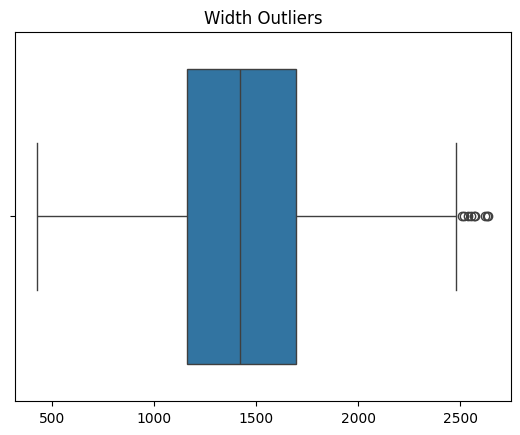

In [16]:
widths = sizes[:,0]
heights = sizes[:,1]

sns.boxplot(x=widths)
plt.title("Width Outliers")
plt.show()

In [17]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn as sns

def compute_brightness(folder, sample_size=300):

    brightness = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = Image.open(os.path.join(folder, file)).convert("L")
        img_array = np.array(img)

        brightness.append(img_array.mean())

    return brightness

In [18]:
normal_brightness = compute_brightness(os.path.join(train_dir,"NORMAL"))
pneumonia_brightness = compute_brightness(os.path.join(train_dir,"PNEUMONIA"))

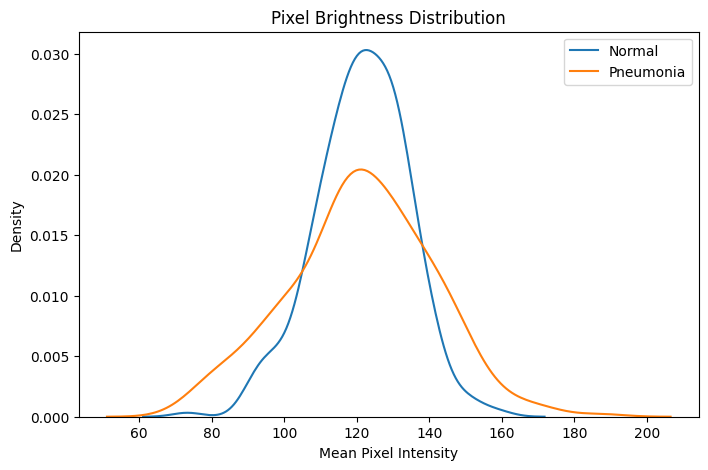

In [19]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_brightness, label="Normal")
sns.kdeplot(pneumonia_brightness, label="Pneumonia")

plt.title("Pixel Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.legend()
plt.show()

Normal images typically show higher average brightness.

In [20]:
from skimage.measure import shannon_entropy

def compute_entropy(folder, sample_size=300):

    entropy_values = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = Image.open(os.path.join(folder,file)).convert("L")
        img_array = np.array(img)

        entropy_values.append(shannon_entropy(img_array))

    return entropy_values

In [21]:
normal_entropy = compute_entropy(os.path.join(train_dir,"NORMAL"))
pneumonia_entropy = compute_entropy(os.path.join(train_dir,"PNEUMONIA"))

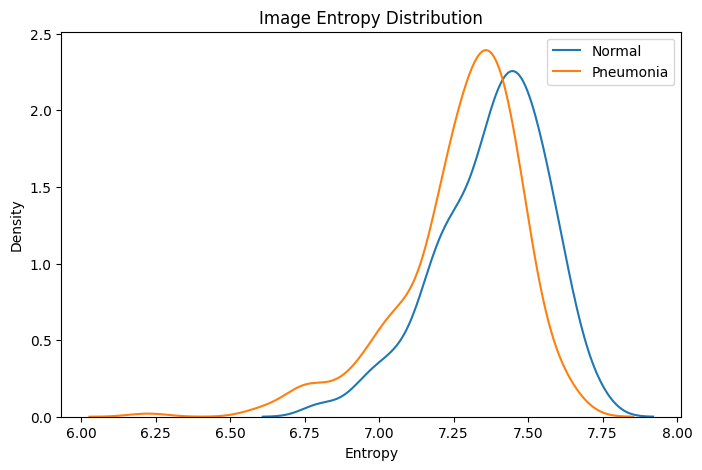

In [22]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_entropy,label="Normal")
sns.kdeplot(pneumonia_entropy,label="Pneumonia")

plt.title("Image Entropy Distribution")
plt.xlabel("Entropy")

plt.legend()
plt.show()

Images exhibit higher entropy due to irregular textures. This means CNN models must capture complex texture patterns rather than simple edges.

In [23]:
from skimage.feature import graycomatrix, graycoprops

def compute_texture(folder, sample_size=200):

    contrast_values = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = Image.open(os.path.join(folder,file)).convert("L")
        img_array = np.array(img)

        glcm = graycomatrix(
            img_array,
            distances=[5],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm,"contrast")[0,0]

        contrast_values.append(contrast)

    return contrast_values

In [24]:
normal_texture = compute_texture(os.path.join(train_dir,"NORMAL"))
pneumonia_texture = compute_texture(os.path.join(train_dir,"PNEUMONIA"))

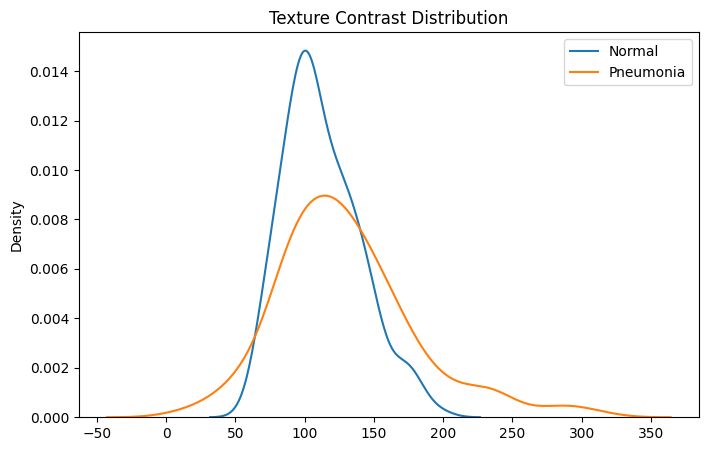

In [25]:
plt.figure(figsize=(8,5))

sns.kdeplot(normal_texture,label="Normal")
sns.kdeplot(pneumonia_texture,label="Pneumonia")

plt.title("Texture Contrast Distribution")

plt.legend()
plt.show()

Normal images show higher texture variability.

In [26]:
import cv2

def compute_sharpness(folder, sample_size=300):

    sharpness_values = []

    files = os.listdir(folder)[:sample_size]

    for file in files:

        img = cv2.imread(os.path.join(folder,file), cv2.IMREAD_GRAYSCALE)

        laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()

        sharpness_values.append(laplacian_var)

    return sharpness_values

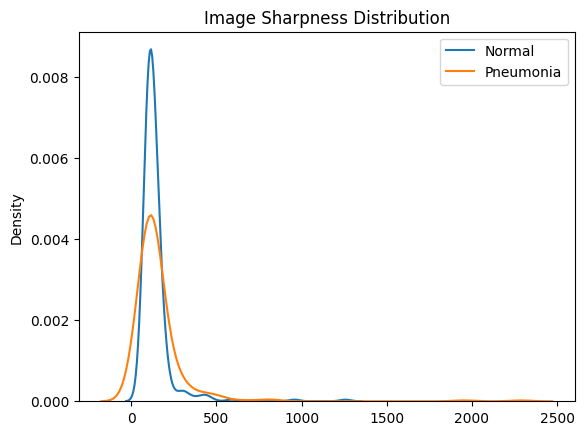

In [27]:
normal_sharp = compute_sharpness(os.path.join(train_dir,"NORMAL"))
pneumonia_sharp = compute_sharpness(os.path.join(train_dir,"PNEUMONIA"))

sns.kdeplot(normal_sharp,label="Normal")
sns.kdeplot(pneumonia_sharp,label="Pneumonia")

plt.title("Image Sharpness Distribution")
plt.legend()
plt.show()

Some images show significantly lower sharpness, indicating acquisition variability.
Image augmentation and normalization may improve robustness.

In [28]:
def brightness_by_split(split_path):

    values = []

    for cls in classes:

        folder = os.path.join(split_path,cls)

        for file in os.listdir(folder)[:200]:

            img = Image.open(os.path.join(folder,file)).convert("L")
            values.append(np.array(img).mean())

    return values

In [29]:
train_brightness = brightness_by_split(train_dir)
test_brightness = brightness_by_split(test_dir)

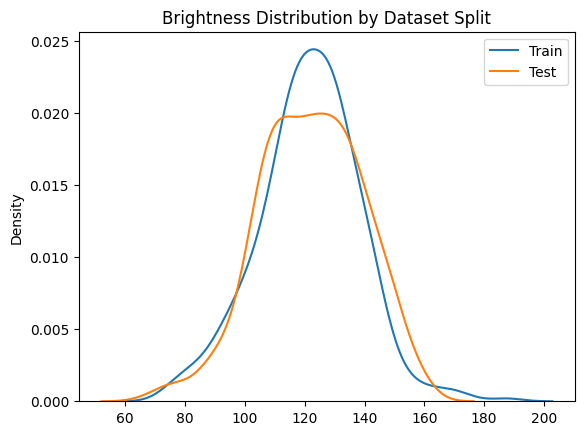

In [30]:
sns.kdeplot(train_brightness,label="Train")
sns.kdeplot(test_brightness,label="Test")

plt.title("Brightness Distribution by Dataset Split")
plt.legend()
plt.show()

Brightness distributions differ slightly between train and test. Normalization and augmentation will be useful.

| Analysis     | Insight                         | Modelling Impact        |
| ------------ | ------------------------------- | ----------------------- |
| Brightness   | Pneumonia lungs appear brighter | Contrast normalization  |
| Entropy      | Pneumonia scans more complex    | CNN texture learning    |
| Texture      | Structural differences          | Deep feature extraction |
| Sharpness    | Variable image quality          | Robust augmentation     |
| Dataset bias | Potential distribution shift    | Careful normalization   |


**Summary:**

The exploratory analysis revealed several important characteristics of the dataset:

Validation dataset is extremely small (16 images), making it unsuitable for reliable model selection. Therefore the validation set will be reconstructed from the training data.

Significant class imbalance exists, with pneumonia cases representing approximately 74% of the training data. Class weighting and data augmentation will be used to mitigate this issue.

Image dimensions vary considerably, requiring resizing to a consistent resolution before training.

Images are stored in grayscale format, and will be normalized and converted to a CNN-compatible representation.

These insights directly inform the design of the preprocessing pipeline and the architecture of the convolutional neural network used for pneumonia detection.

## Preprocessing

In [39]:
from sklearn.model_selection import train_test_split
from pathlib import Path

In [40]:
normal_paths = list(Path(path + "/chest_xray/chest_xray/train/NORMAL").glob("*.jpeg"))
pneumonia_paths = list(Path(path + "/chest_xray/chest_xray/train/PNEUMONIA").glob("*.jpeg"))

image_paths = normal_paths + pneumonia_paths
labels = [0]*len(normal_paths) + [1]*len(pneumonia_paths)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

Total images: 5216


In [41]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 3651
Validation: 782
Test: 783


In [42]:
IMG_SIZE = 224

def preprocess_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=1)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [49]:
"""def augment(image, label):

    image = tf.image.random_flip_left_right(image)

    image = tf.image.random_brightness(image, 0.1)

    image = tf.image.random_contrast(image, 0.9, 1.1)

    image = tf.image.random_crop(
        tf.image.resize_with_pad(image, 230, 230),
        size=[224,224,1]
    )

    return image, label
"""
geom_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # keep just one
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
])

def augment(image, label):
    # geometric augmentations
    image = geom_augment(image)

    # pixel-level augmentations
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)

    # resize + random crop
    image = tf.image.random_crop(
        tf.image.resize_with_pad(image, 230, 230),
        size=[224, 224, 1]
    )

    return image, label

In [50]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def build_dataset(paths, labels, training=False):

    paths = [str(p) for p in paths]

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        dataset = dataset.map(augment, num_parallel_calls=AUTOTUNE)
        dataset = dataset.shuffle(2000)

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [51]:
train_dataset = build_dataset(X_train, y_train, training=True)

val_dataset = build_dataset(X_val, y_val)

test_dataset = build_dataset(X_test, y_test)

In [52]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [53]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9440894568690097), 1: np.float64(0.6731194690265486)}


In [54]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 1)
(32,)
